In [261]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind
import statsmodels.stats.api as sm

In [3]:
mydata=pd.read_csv("C:\\Users\\bfood\\Downloads\\Wholesale+Customers+Data.csv")
mydata.head()

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,1,Retail,Other,12669,9656,7561,214,2674,1338
1,2,Retail,Other,7057,9810,9568,1762,3293,1776
2,3,Retail,Other,6353,8808,7684,2405,3516,7844
3,4,Hotel,Other,13265,1196,4221,6404,507,1788
4,5,Retail,Other,22615,5410,7198,3915,1777,5185


In [4]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 9 columns):
Buyer/Spender       440 non-null int64
Channel             440 non-null object
Region              440 non-null object
Fresh               440 non-null int64
Milk                440 non-null int64
Grocery             440 non-null int64
Frozen              440 non-null int64
Detergents_Paper    440 non-null int64
Delicatessen        440 non-null int64
dtypes: int64(7), object(2)
memory usage: 31.1+ KB


In [6]:
d1=mydata.iloc[:,1:]
d1.describe().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,3.00,55.00,3.00,25.00,3.00,3.00
25%,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


In [7]:
mydata.head()

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,1,Retail,Other,12669,9656,7561,214,2674,1338
1,2,Retail,Other,7057,9810,9568,1762,3293,1776
2,3,Retail,Other,6353,8808,7684,2405,3516,7844
3,4,Hotel,Other,13265,1196,4221,6404,507,1788
4,5,Retail,Other,22615,5410,7198,3915,1777,5185


In [8]:
mydata.tail()

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
435,436,Hotel,Other,29703,12051,16027,13135,182,2204
436,437,Hotel,Other,39228,1431,764,4510,93,2346
437,438,Retail,Other,14531,15488,30243,437,14841,1867
438,439,Hotel,Other,10290,1981,2232,1038,168,2125
439,440,Hotel,Other,2787,1698,2510,65,477,52


In [16]:
mydata.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,Retail,Other,12669,9656,7561,214,2674,1338
1,Retail,Other,7057,9810,9568,1762,3293,1776
2,Retail,Other,6353,8808,7684,2405,3516,7844
3,Hotel,Other,13265,1196,4221,6404,507,1788
4,Retail,Other,22615,5410,7198,3915,1777,5185


In [39]:
Table=pd.pivot_table(mydata,index=["Region"],
                    values=["Fresh","Milk","Grocery", "Frozen","Detergents_Paper", "Delicatessen"])
Table.round(2)

,Delicatessen,Detergents_Paper,Fresh,Frozen,Grocery,Milk
Region,,,,,,
Lisbon,1354.9,2651.12,11101.73,3000.34,7403.08,5486.42
Oporto,1159.7,3687.47,9887.68,4045.36,9218.60,5088.17
Other,1620.6,2817.75,12533.47,2944.59,7896.36,5977.09


In [40]:
Table=pd.pivot_table(mydata,index=["Channel"],
                    values=["Fresh","Milk","Grocery", "Frozen","Detergents_Paper", "Delicatessen",])
Table.round(2)

,Delicatessen,Detergents_Paper,Fresh,Frozen,Grocery,Milk
Channel,,,,,,
Hotel,1415.96,790.56,13475.56,3748.25,3962.14,3451.72
Retail,1753.44,7269.51,8904.32,1652.61,16322.85,10716.50


In [21]:
mydata.describe().T

,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicatessen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [22]:
mydata.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Channel,440,2,Hotel,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,440,3,Other,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fresh,440,NaN,NaN,NaN,12000.3,12647.3,3,3127.75,8504,16933.8,112151
Milk,440,NaN,NaN,NaN,5796.27,7380.38,55,1533,3627,7190.25,73498
Grocery,440,NaN,NaN,NaN,7951.28,9503.16,3,2153,4755.5,10655.8,92780
Frozen,440,NaN,NaN,NaN,3071.93,4854.67,25,742.25,1526,3554.25,60869
Detergents_Paper,440,NaN,NaN,NaN,2881.49,4767.85,3,256.75,816.5,3922,40827
Delicatessen,440,NaN,NaN,NaN,1524.87,2820.11,3,408.25,965.5,1820.25,47943


In [97]:
mydata['Spending'] = mydata ['Fresh']+ mydata ['Milk']+ mydata ['Grocery']+ mydata ['Frozen']+ mydata ['Detergents_Paper']+ mydata ['Delicatessen']
mydata.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Spending
0,Retail,Other,12669,9656,7561,214,2674,1338,34112
1,Retail,Other,7057,9810,9568,1762,3293,1776,33266
2,Retail,Other,6353,8808,7684,2405,3516,7844,36610
3,Hotel,Other,13265,1196,4221,6404,507,1788,27381
4,Retail,Other,22615,5410,7198,3915,1777,5185,46100


In [98]:
regiondf = mydata.groupby('Region')['Spending'].sum()
print(regiondf)
print()
channeldf = mydata.groupby('Channel')['Spending'].sum()
print(channeldf)

Region
Lisbon     2386813
Oporto     1555088
Other     10677599
Name: Spending, dtype: int64

Channel
Hotel     7999569
Retail    6619931
Name: Spending, dtype: int64


Text(0.5, 1, 'Item - Fresh')

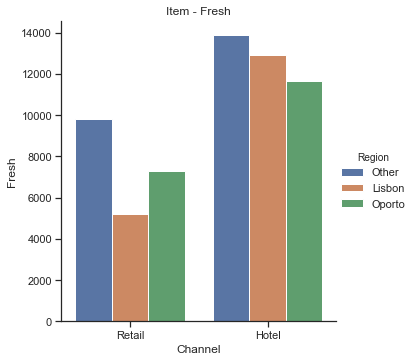

In [29]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Fresh", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Item - Fresh')

Text(0.5, 1, 'Item - Fresh')

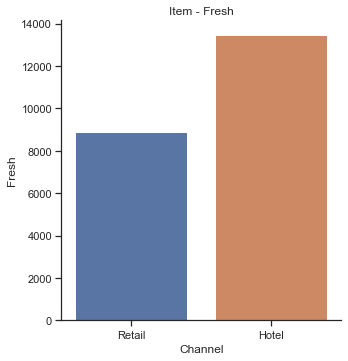

In [31]:
sns.catplot(x="Channel", y="Fresh", kind="bar", ci=None, data=mydata)
plt.title('Item - Fresh')

Text(0.5, 1, 'Item - Fresh')

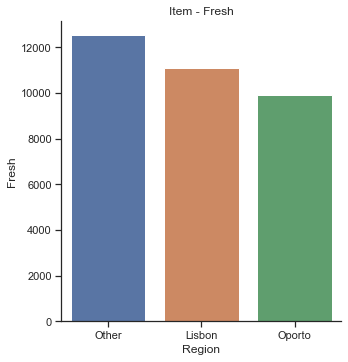

In [32]:
sns.catplot(x="Region", y="Fresh", kind="bar", ci=None, data=mydata)
plt.title('Item - Fresh')

Text(0.5, 1, 'Item - Milk')

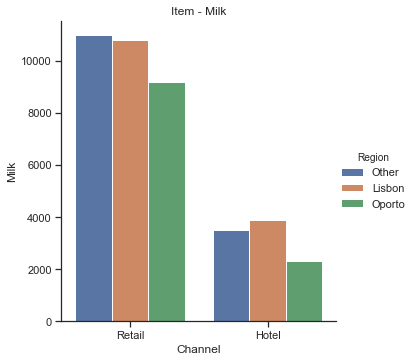

In [41]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Milk", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Item - Milk')

Text(0.5, 1, 'Item - Milk')

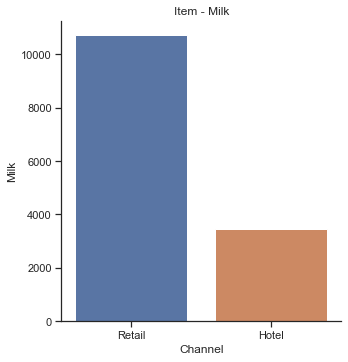

In [43]:
sns.catplot(x="Channel", y="Milk", kind="bar", ci=None, data=mydata)
plt.title('Item - Milk')

Text(0.5, 1, 'Item - Milk')

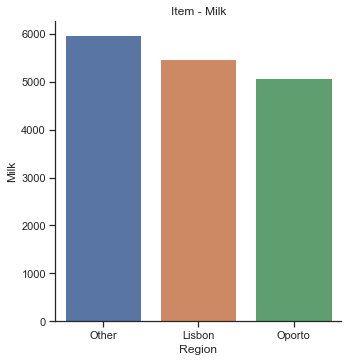

In [44]:
sns.catplot(x="Region", y="Milk", kind="bar", ci=None, data=mydata)
plt.title('Item - Milk')

Text(0.5, 1, 'Item - Grocery')

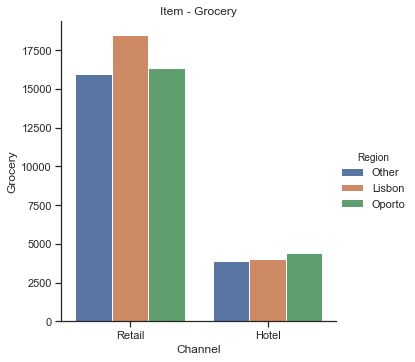

In [45]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Grocery", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Item - Grocery')

Text(0.5, 1, 'Item - Grocery')

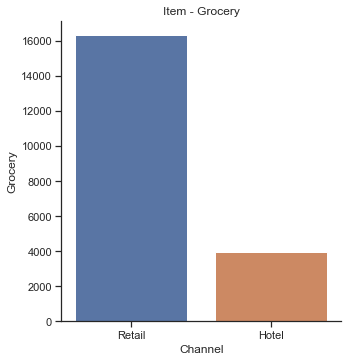

In [46]:
sns.catplot(x="Channel", y="Grocery", kind="bar", ci=None, data=mydata)
plt.title('Item - Grocery')

Text(0.5, 1, 'Item - Grocery')

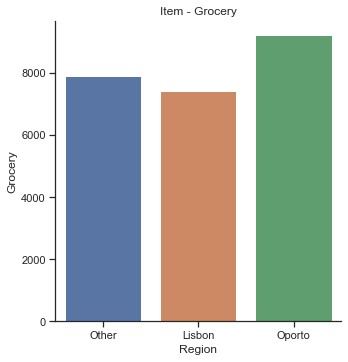

In [47]:
sns.catplot(x="Region", y="Grocery", kind="bar", ci=None, data=mydata)
plt.title('Item - Grocery')

Text(0.5, 1, 'Item - Frozen')

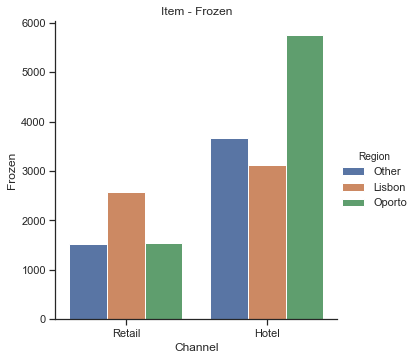

In [48]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Frozen", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Item - Frozen')

Text(0.5, 1, 'Item - Frozen')

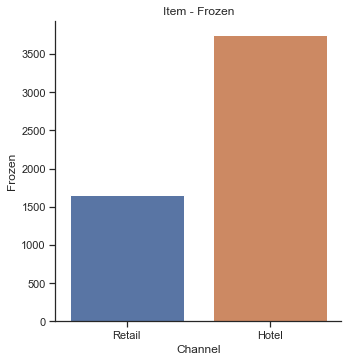

In [49]:
sns.catplot(x="Channel", y="Frozen", kind="bar", ci=None, data=mydata)
plt.title('Item - Frozen')

Text(0.5, 1, 'Item - Frozen')

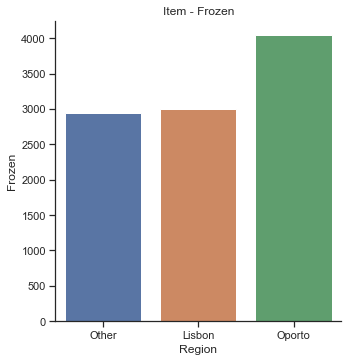

In [50]:
sns.catplot(x="Region", y="Frozen", kind="bar", ci=None, data=mydata)
plt.title('Item - Frozen')

Text(0.5, 1, 'Item - Detergents_Paper')

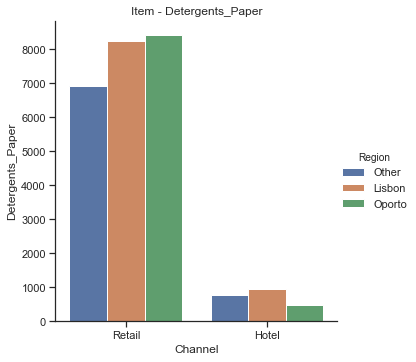

In [55]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Detergents_Paper", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Item - Detergents_Paper')

Text(0.5, 1, 'Item - Detergents_Paper')

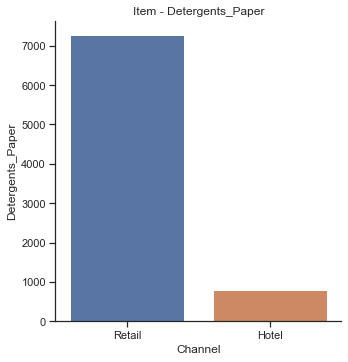

In [57]:
sns.catplot(x="Channel", y="Detergents_Paper", kind="bar", ci=None, data=mydata)
plt.title('Item - Detergents_Paper')

Text(0.5, 1, 'Item - Detergents_Paper')

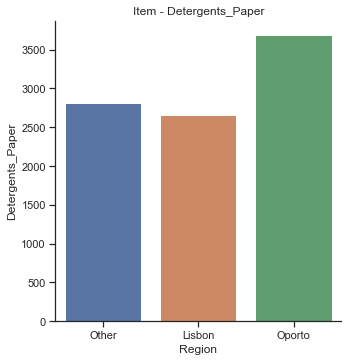

In [58]:
sns.catplot(x="Region", y="Detergents_Paper", kind="bar", ci=None, data=mydata)
plt.title('Item - Detergents_Paper')

Text(0.5, 1, 'Delicatessen')

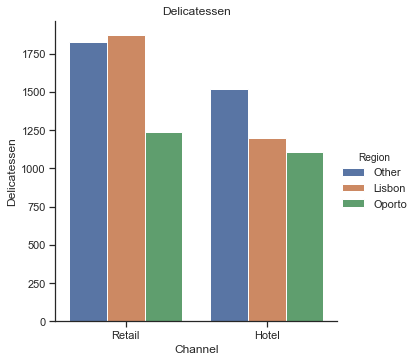

In [60]:
sns.set(style="ticks", color_codes=True)
sns.catplot(x="Channel", y="Delicatessen", hue ="Region", kind="bar", ci=None, data=mydata)
plt.title('Delicatessen')

Text(0.5, 1, 'Item - Delicatessen')

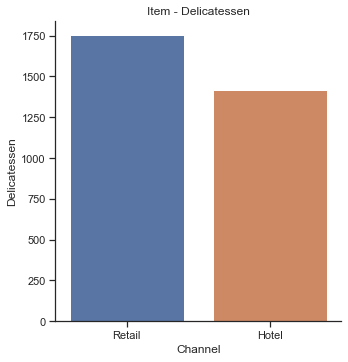

In [61]:
sns.catplot(x="Channel", y="Delicatessen", kind="bar", ci=None, data=mydata)
plt.title('Item - Delicatessen')

Text(0.5, 1, 'Item - Delicatessen')

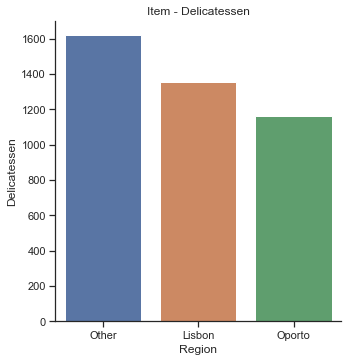

In [63]:
sns.catplot(x="Region", y="Delicatessen", kind="bar", ci=None, data=mydata)
plt.title('Item - Delicatessen')

In [86]:
df=mydata.T

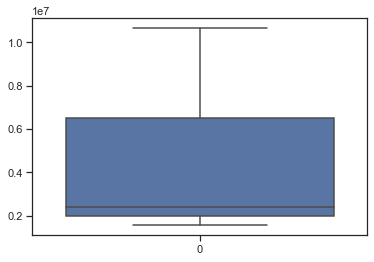

In [94]:
sns.boxplot(data=regiondf)
plt.show()

In [127]:
products = mydata[mydata.columns[+2:mydata.columns.size]]
products

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


In [104]:
standard_deviation_items = products.std()
standard_deviation_items.round(2)

Fresh               12647.33
Milk                 7380.38
Grocery              9503.16
Frozen               4854.67
Detergents_Paper     4767.85
Delicatessen         2820.11
Spending            26356.30
dtype: float64

In [106]:
cv_fresh = np.std(products['Fresh']) / np.mean(products['Fresh'])
cv_fresh

1.0527196084948245

In [107]:
cv_milk = np.std(products['Milk']) / np.mean(products['Milk'])
cv_milk


1.2718508307424503

In [108]:
cv_grocery = np.std(products['Grocery']) / np.mean(products['Grocery'])
cv_grocery


1.193815447749267

In [109]:
cv_frozen = np.std(products['Frozen']) / np.mean(products['Frozen'])
cv_frozen


1.5785355298607762

In [110]:
cv_detergents_paper = np.std(products['Detergents_Paper']) / np.mean(products['Detergents_Paper'])
cv_detergents_paper


1.6527657881041729

In [111]:
cv_delicatessen = np.std(products['Delicatessen']) / np.mean(products['Delicatessen'])
cv_delicatessen

1.8473041039189306

In [113]:
from scipy.stats import variation
variation(products, axis = 0)

array([1.05271961, 1.27185083, 1.19381545, 1.57853553, 1.65276579,
       1.8473041 , 0.79233812])

In [119]:
variance_items = products.var()
print(variance_items)

Fresh               1.599549e+08
Milk                5.446997e+07
Grocery             9.031010e+07
Frozen              2.356785e+07
Detergents_Paper    2.273244e+07
Delicatessen        7.952997e+06
Spending            6.946546e+08
dtype: float64


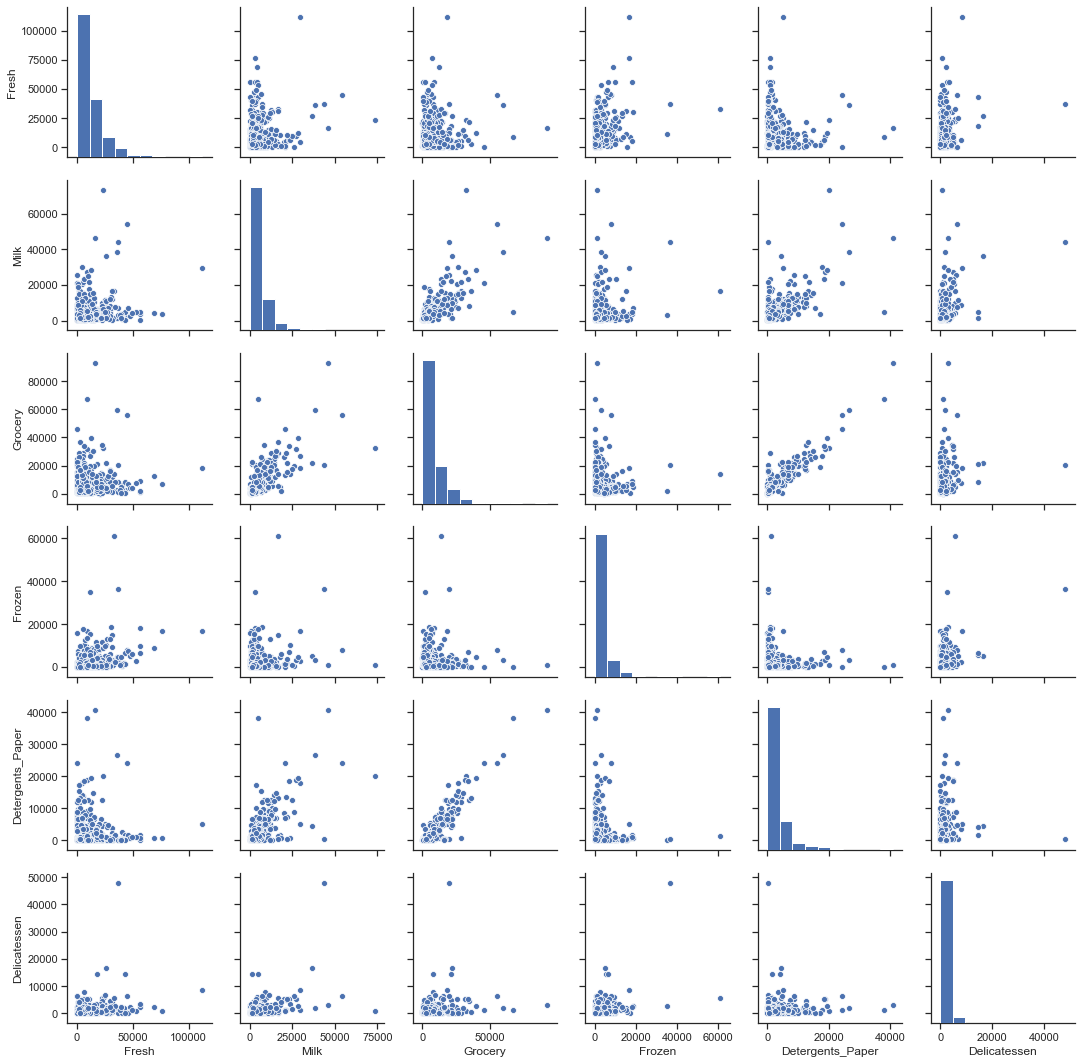

In [122]:
sn.pairplot(data=mydata)

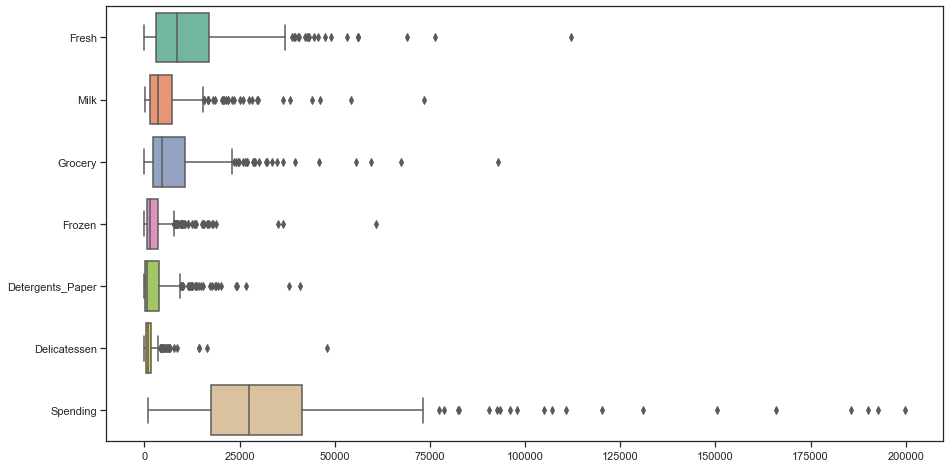

In [123]:
plt.figure(figsize=(15,8))
sns.boxplot(data=products, orient="h", palette="Set2")

In [125]:
mydata

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,Retail,Other,12669,9656,7561,214,2674,1338
1,Retail,Other,7057,9810,9568,1762,3293,1776
2,Retail,Other,6353,8808,7684,2405,3516,7844
3,Hotel,Other,13265,1196,4221,6404,507,1788
4,Retail,Other,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,Hotel,Other,29703,12051,16027,13135,182,2204
436,Hotel,Other,39228,1431,764,4510,93,2346
437,Retail,Other,14531,15488,30243,437,14841,1867
438,Hotel,Other,10290,1981,2232,1038,168,2125


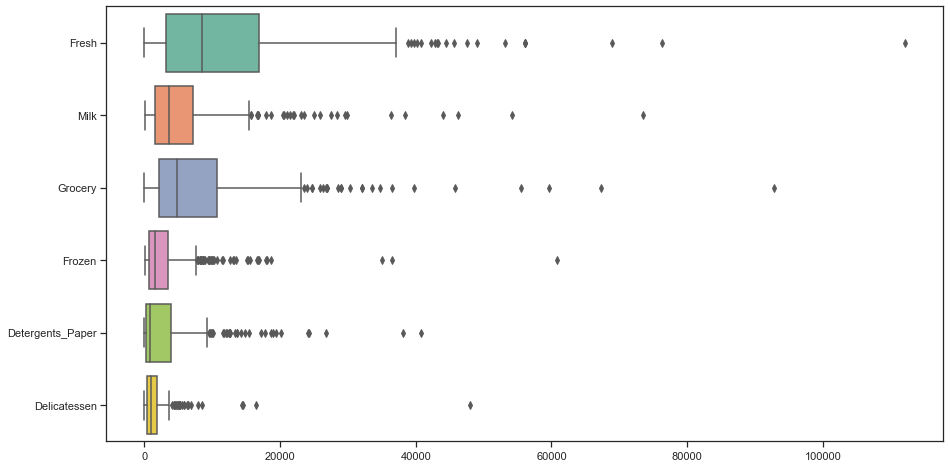

In [128]:
plt.figure(figsize=(15,8))
sns.boxplot(data=products, orient="h", palette="Set2")

In [274]:
df=pd.read_csv("Survey-1.csv")
df.head(10)

,ID,Gender,Age,Class,Major,Grad Intention,GPA,Employment,Salary,Social Networking,Satisfaction,Spending,Computer,Text Messages
0,1,Female,20,Junior,Other,Yes,2.9,Full-Time,50.0,1,3,350,Laptop,200
1,2,Male,23,Senior,Management,Yes,3.6,Part-Time,25.0,1,4,360,Laptop,50
2,3,Male,21,Junior,Other,Yes,2.5,Part-Time,45.0,2,4,600,Laptop,200
3,4,Male,21,Junior,CIS,Yes,2.5,Full-Time,40.0,4,6,600,Laptop,250
4,5,Male,23,Senior,Other,Undecided,2.8,Unemployed,40.0,2,4,500,Laptop,100
5,6,Female,22,Senior,Economics/Finance,Undecided,2.3,Unemployed,78.0,3,2,700,Laptop,30
6,7,Female,21,Junior,Other,Undecided,3.0,Part-Time,50.0,1,3,500,Laptop,50
7,8,Female,22,Senior,Other,Undecided,3.1,Full-Time,80.0,1,2,200,Tablet,300
8,9,Female,20,Junior,Management,Yes,3.6,Unemployed,30.0,0,4,500,Laptop,400
9,10,Female,21,Senior,Economics/Finance,Undecided,3.3,Part-Time,37.5,1,4,200,Laptop,100


In [276]:
pd.crosstab(df.Gender, df.Major)

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,3,3,7,4,4,3,9,0
Male,4,1,4,2,6,4,5,3


In [277]:
pd.crosstab(df.Gender, df['Grad Intention'])

Grad Intention,No,Undecided,Yes
Gender,,,
Female,9,13,11
Male,3,9,17


In [278]:
pd.crosstab(df.Gender, df['Employment'])


Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Female,3,24,6
Male,7,19,3


In [279]:
pd.crosstab(df.Gender, df['Computer'])

Computer,Desktop,Laptop,Tablet
Gender,,,
Female,2,29,2
Male,3,26,0


In [218]:
df.groupby(["Gender"]).count()

,ID,Age,Class,Major,Grad Intention,GPA,Employment,Salary,Social Networking,Satisfaction,Spending,Computer,Text Messages
Gender,,,,,,,,,,,,,
Female,33,33,33,33,33,33,33,33,33,33,33,33,33
Male,29,29,29,29,29,29,29,29,29,29,29,29,29


In [280]:
pd.crosstab(df['Gender'], df['Major'],margins = True,normalize='index')

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,0.090909,0.090909,0.212121,0.121212,0.121212,0.090909,0.272727,0.000000
Male,0.137931,0.034483,0.137931,0.068966,0.206897,0.137931,0.172414,0.103448
All,0.112903,0.064516,0.177419,0.096774,0.161290,0.112903,0.225806,0.048387


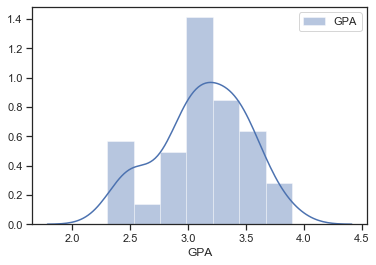

In [222]:
sn.distplot(df["GPA"],label="GPA")
plt.legend()

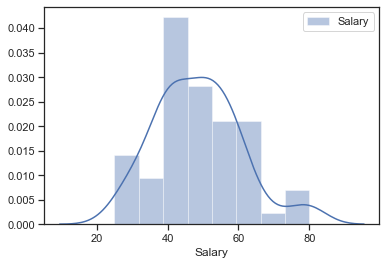

In [223]:
sn.distplot(df["Salary"],label="Salary")
plt.legend()

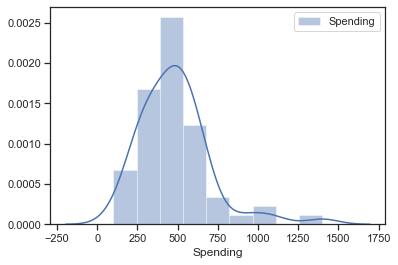

In [224]:
sn.distplot(df["Spending"],label="Spending")
plt.legend()

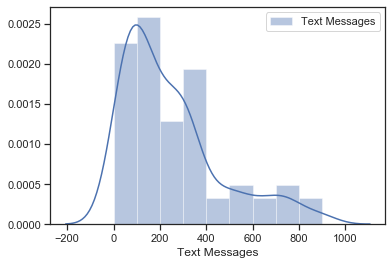

In [225]:
sn.distplot(df["Text Messages"],label="Text Messages")
plt.legend()

In [228]:
df3=pd.read_csv("A+&+B+shingles.csv")
df3.head(10)

,A,B
0,0.44,0.14
1,0.61,0.15
2,0.47,0.31
3,0.30,0.16
4,0.15,0.37
5,0.24,0.18
6,0.16,0.42
7,0.20,0.58
8,0.20,0.25
9,0.20,0.41


In [243]:
df3.describe()

,A,B
count,36.000000,31.000000
mean,0.316667,0.273548
std,0.135731,0.137296
min,0.130000,0.100000
25%,0.207500,0.160000
50%,0.290000,0.230000
75%,0.392500,0.400000
max,0.720000,0.580000


In [262]:
df3.isnull().sum()

A    0
B    5
dtype: int64

In [264]:
df3.shape

(36, 2)

In [265]:
df3.describe().T

,count,mean,std,min,25%,50%,75%,max
A,36.0,0.316667,0.135731,0.13,0.2075,0.29,0.3925,0.72
B,31.0,0.273548,0.137296,0.10,0.1600,0.23,0.4000,0.58


In [267]:
t_statistic, p_value = ttest_1samp(df3['A'],0.35, nan_policy='omit')
print('tstat',t_statistic)    
print('P Value',p_value/2)

tstat -1.4735046253382782
P Value 0.07477633144907513


In [268]:
print ("one-sample t-test p-value=", p_value/2)

alpha_level = 0.05

if (p_value/2) < alpha_level:
    print('We have enough evidence to reject the null hypothesis in favour of alternative hypothesis')
    
else:
    print('We do not have enough evidence to reject the null hypothesis in favour of alternative hypothesis')
    print('We conclude that the moisture content is greater than permissible limit in sample A.')

one-sample t-test p-value= 0.07477633144907513
We do not have enough evidence to reject the null hypothesis in favour of alternative hypothesis
We conclude that the moisture content is greater than permissible limit in sample A.


In [269]:
t_statistic, p_value = ttest_1samp(df3['B'],0.35, nan_policy='omit')
print('tstat',t_statistic)    
print('P Value',p_value/2)

tstat -3.1003313069986995
P Value 0.0020904774003191826


In [270]:
print ("one-sample t-test p-value=", p_value/2)

alpha_level = 0.05

if (p_value/2) < alpha_level:
    print('We have enough evidence to reject the null hypothesis in favour of alternative hypothesis')
    print('We conclude that the moisture content is less than permissible limit in sample B.')
    
else:
    print('We do not have enough evidence to reject the null hypothesis in favour of alternative hypothesis')

one-sample t-test p-value= 0.0020904774003191826
We have enough evidence to reject the null hypothesis in favour of alternative hypothesis
We conclude that the moisture content is less than permissible limit in sample B.


In [272]:
t_statistic, p_value  = ttest_ind(df3['A'],df3['B'],nan_policy='omit')
print('tstat',t_statistic)    
print('P Value',p_value)

tstat 1.2896282719661123
P Value 0.2017496571835306


In [273]:
print ("two-sample t-test p-value=", p_value)

alpha_level = 0.05

if p_value < alpha_level:
    print('We have enough evidence to reject the null hypothesis in favour of alternative hypothesis')

else:
    print('We do not have enough evidence to reject the null hypothesis in favour of alternative hypothesis')
    print('We conclude that mean for shingles A and singles B are not the same')

two-sample t-test p-value= 0.2017496571835306
We do not have enough evidence to reject the null hypothesis in favour of alternative hypothesis
We conclude that mean for shingles A and singles B are not the same
